In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [32]:
dfRead = pd.read_csv(r"Analyse/data.csv")
print (len(dfRead))
print (dfRead.columns.tolist())
spaltenList = ['datum', 'stunde', 'temperatur', 'luftfeuchtigkeit',  'windgeschwindigkeit', 'windrichtung',  'luftdruck', 'niederschlagshoehe_mm', 'sonnenscheindauer_minuten',  'gesamtbewoelkung', 'no2']
dfO = dfRead[spaltenList].copy()
#print (df.columns.tolist())
print(dfO.index)
print(dfO.dtypes)
print (dfO.describe ())


394488
['station', 'datum', 'stunde', 'datumstunde', 'qualitaetsniveau_temperatur', 'temperatur', 'luftfeuchtigkeit', 'qualitaetsniveau_windgeschwindigkeit', 'windgeschwindigkeit', 'windrichtung', 'qualitaetsniveau_luftfeuchtigkeit', 'absolute_feuchtigkeit', 'dampfdruck', 'feuchttemperatur', 'luftdruck', 'temperatur_2m', 'relative_luftfeuchtigkeit', 'taupunkttemperatur', 'qualitaetsniveau_niederschlag', 'niederschlagshoehe_mm', 'niederschlag_indikator', 'niederschlagsart', 'qualitaetsniveau_sonneneinstrahlung', 'sonnenscheindauer_minuten', 'qualitaetsniveau_bewoelkung', 'messart_bewoelkung', 'gesamtbewoelkung', 'o3', 'no2', 'pm10']
RangeIndex(start=0, stop=394488, step=1)
datum                         object
stunde                         int64
temperatur                   float64
luftfeuchtigkeit             float64
windgeschwindigkeit          float64
windrichtung                 float64
luftdruck                    float64
niederschlagshoehe_mm        float64
sonnenscheindauer_minut

<Axes: xlabel='datum'>

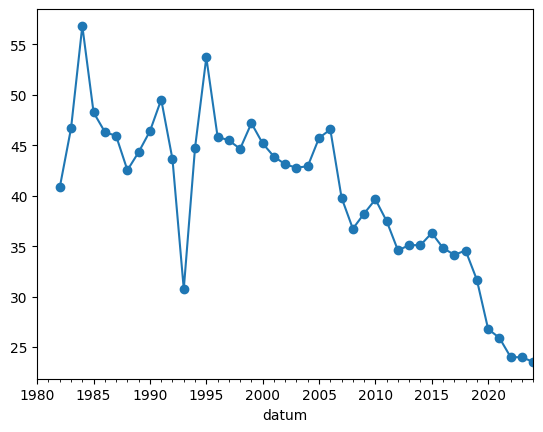

In [3]:
# Jahresmittelwert nur berechnen, wenn das Jahr zu 50% vollständig ist
df = dfO.copy ()
df['datum'] = pd.to_datetime(dfO['datum'], errors='coerce')
df.set_index('datum', inplace=True)
min_hours_per_year = int(8760 * 0.7)
stoff = 'no2'
annual_trend = df[stoff].resample('YE').apply(lambda x: x.mean() if x.notna().sum() >= min_hours_per_year else None)

annual_trend.plot(marker='o')

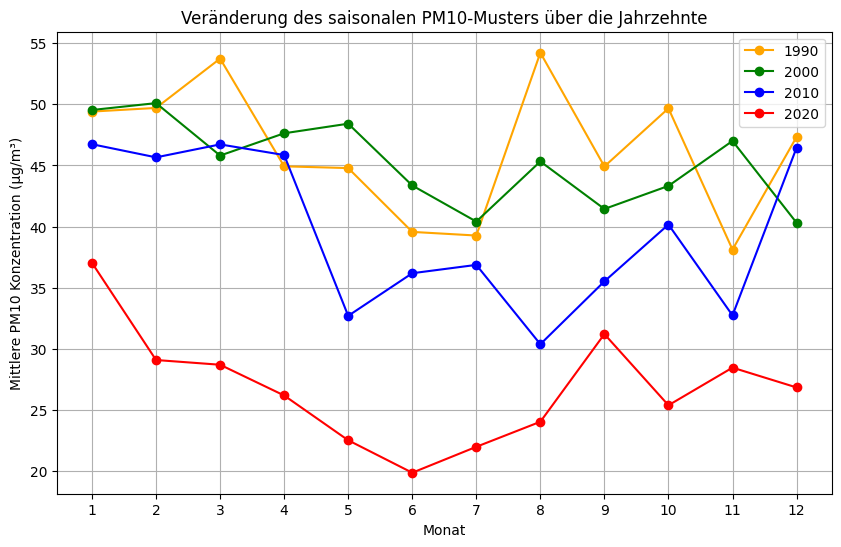

In [4]:
## Methode: Saisonaler Mittelwert im Langzeitvergleich
# Gruppieren nach Jahr und Monat, um den Mittelwert zu berechnen
df = dfO.copy ()
df['datum'] = pd.to_datetime(dfO['datum'], errors='coerce')
df.set_index('datum', inplace=True)
monthly_means = df.groupby([df.index.year, df.index.month])[stoff].mean().unstack()

# Plotten der Kurven für ausgewählte Jahrzehnte zum Vergleich
plt.figure(figsize=(10, 6))
plt.plot(monthly_means.loc[1990], label='1990', color='orange', marker='o')
plt.plot(monthly_means.loc[2000], label='2000', color='green', marker='o')
plt.plot(monthly_means.loc[2010], label='2010', color='blue', marker='o')
plt.plot(monthly_means.loc[2020], label='2020', color='red', marker='o')
plt.title('Veränderung des saisonalen PM10-Musters über die Jahrzehnte')
plt.xlabel('Monat')
plt.ylabel('Mittlere PM10 Konzentration (µg/m³)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()

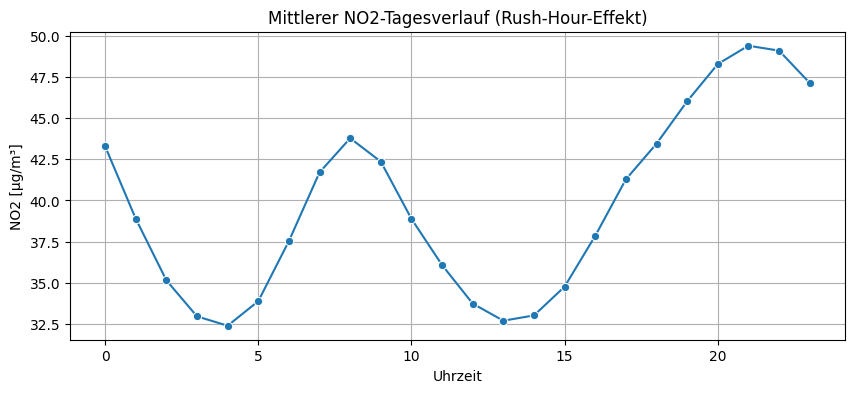

In [5]:

# Datentypen korrigieren und Zeitstempel bauen
df = dfO.copy ()
df['datum'] = pd.to_datetime(df['datum'])
# Falls 'stunde' als Ganzzahl (0-23) vorliegt, in Timedelta umwandeln
df['timestamp'] = df['datum'] + pd.to_timedelta(df['stunde'], unit='h')
df.set_index('timestamp', inplace=True)

# Nicht mehr benötigte Spalten entfernen
df.drop(columns=['datum', 'stunde'], inplace=True)
# Hilfsspalten für die Gruppierung anlegen
df['Hour'] = df.index.hour
df['Weekday'] = df.index.weekday # 0=Montag, 6=Sonntag
df['Month'] = df.index.month

# Plot 1: Der typische Tagesverlauf (Berufsverkehr)
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Hour', y='no2', errorbar=None, marker="o")
plt.title("Mittlerer NO2-Tagesverlauf (Rush-Hour-Effekt)")
plt.xlabel("Uhrzeit")
plt.ylabel("NO2 [µg/m³]")
plt.grid(True)
plt.show()

Korrelation mit NO2:
 no2                          1.000000
Hour                         0.146400
luftfeuchtigkeit             0.093421
luftdruck                    0.073456
niederschlagshoehe_mm       -0.034995
sonnenscheindauer_minuten   -0.073182
Month                       -0.073476
Weekday                     -0.128324
windrichtung                -0.174436
temperatur                  -0.177468
gesamtbewoelkung            -0.191646
windgeschwindigkeit         -0.249246
Name: no2, dtype: float64


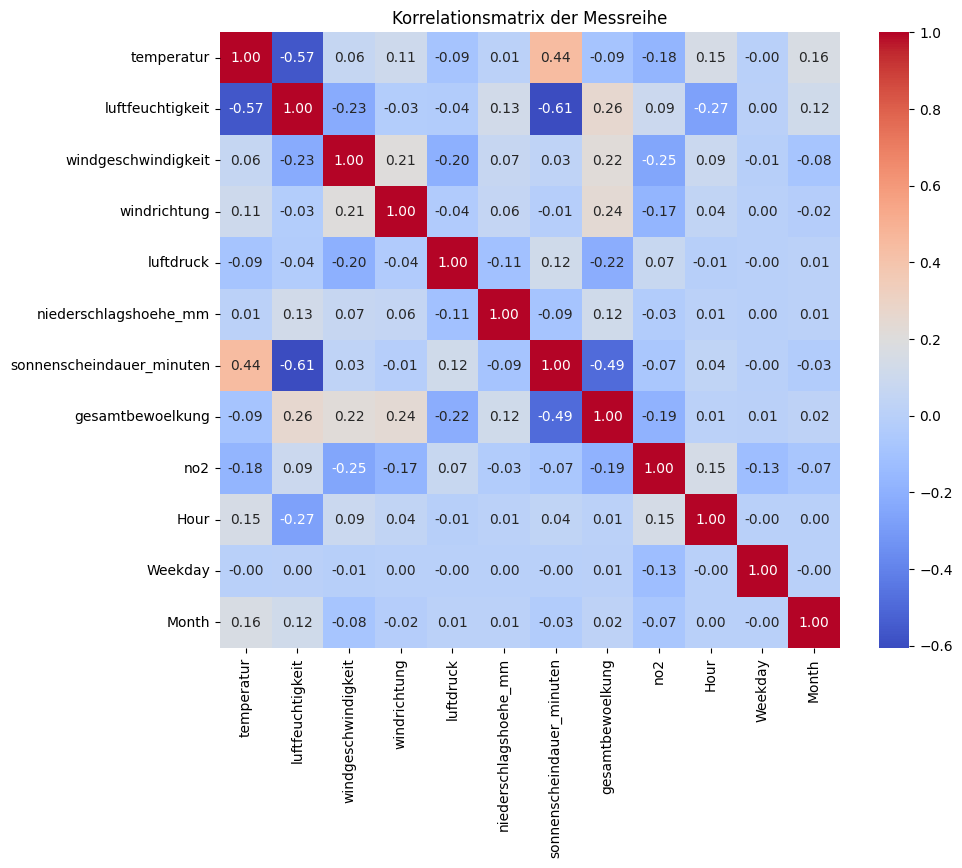

In [6]:
# Korrelation aller numerischen Werte zu NO2 berechnen
korrelationen = df.corr()['no2'].sort_values(ascending=False)
print("Korrelation mit NO2:\n", korrelationen)

# Visuelle Heatmap für den Überblick
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korrelationsmatrix der Messreihe")
plt.show()

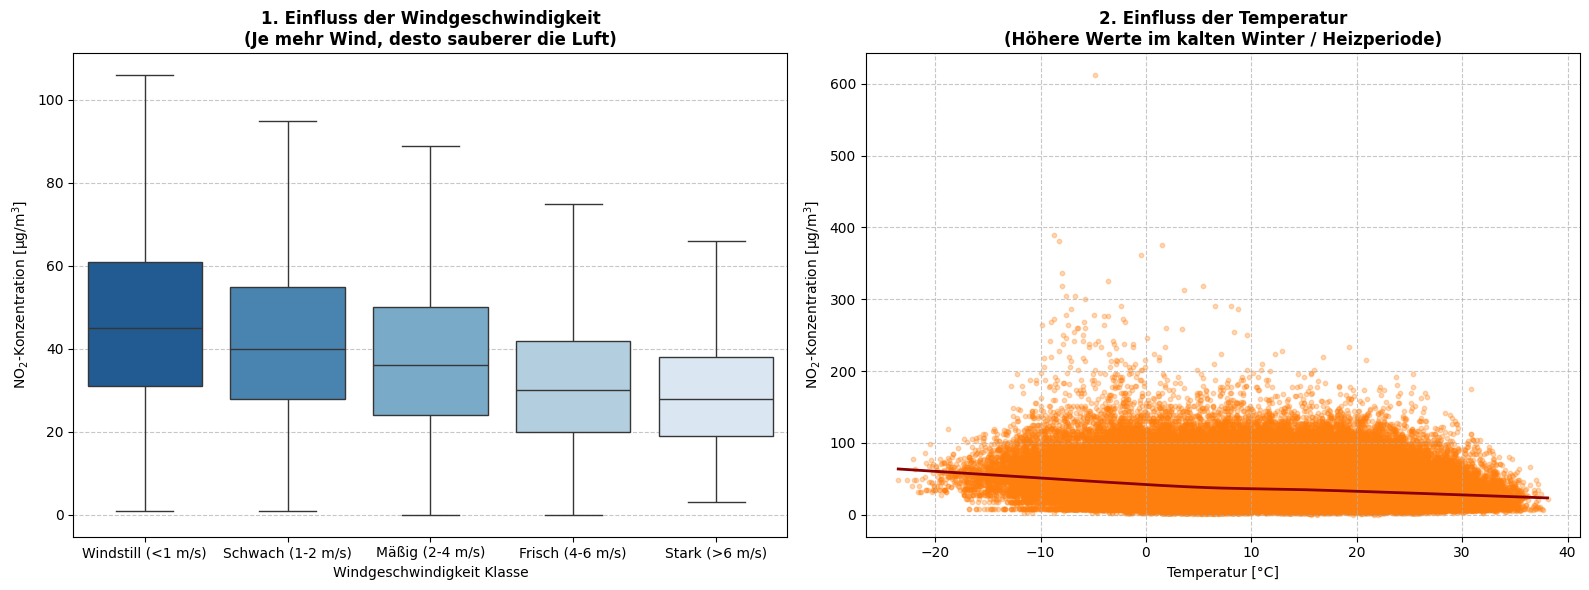

In [7]:
# Figure mit zwei Diagrammen nebeneinander erstellen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- DIAGRAMM 1: Windgeschwindigkeit (Zukunftssichere Syntax) ---
df['Windklasse'] = pd.cut(df['windgeschwindigkeit'], 
                          bins=[-1, 1, 2, 4, 6, 12], 
                          labels=['Windstill (<1 m/s)', 'Schwach (1-2 m/s)', 'Mäßig (2-4 m/s)', 'Frisch (4-6 m/s)', 'Stark (>6 m/s)'])

# x an hue übergeben und legend=False setzen
sns.boxplot(ax=ax1, data=df, x='Windklasse', y='no2', hue='Windklasse', palette='Blues_r', showfliers=False, legend=False)

# Fehlerbehebung: r'' vor den String gesetzt, um LaTeX-Formeln zu erlauben
ax1.set_title(r'1. Einfluss der Windgeschwindigkeit' + '\n' + r'(Je mehr Wind, desto sauberer die Luft)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Windgeschwindigkeit Klasse')
ax1.set_ylabel(r'$\mathrm{NO_2}$-Konzentration [$\mathrm{\mu g/m^3}$]')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- DIAGRAMM 2: Temperatur & Inversions-Effekt ---
sns.regplot(ax=ax2, data=df, x='temperatur', y='no2', 
            scatter_kws={'alpha':0.3, 'color':'tab:orange', 's':10}, 
            line_kws={'color':'darkred', 'linewidth':2}, lowess=True)
ax2.set_title(r'2. Einfluss der Temperatur' + '\n' + r'(Höhere Werte im kalten Winter / Heizperiode)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Temperatur [°C]')
ax2.set_ylabel(r'$\mathrm{NO_2}$-Konzentration [$\mathrm{\mu g/m^3}$]')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
# Einteilung der Windrichtung in 8 Sektoren (N, NO, O, SO, S, SW, W, NW)
df['windrichtung_sektor'] = pd.cut(df['windrichtung'], 
                                   bins=[0, 45, 90, 135, 180, 225, 270, 315, 360], 
                                   labels=['N', 'NO', 'O', 'SO', 'S', 'SW', 'W', 'NW'],
                                   include_lowest=True)

# Mittlere NO2-Konzentration pro Windrichtung
wind_no2 = df.groupby('windrichtung_sektor', observed=False)['no2'].mean()
print(wind_no2)

windrichtung_sektor
N     41.106592
NO    46.017256
O     45.982381
SO    38.741885
S     36.780311
SW    35.479789
W     34.081982
NW    36.041552
Name: no2, dtype: float64


In [13]:
df = dfRead.copy ()
# Definition einer Smogwetterlage (Inversion/Stagnation)
# - Windgeschwindigkeit < 1.5 m/s (Luft steht)
# - Temperatur < 5°C (Heizperiode / Inversionsrisiko)
smog_maske = (df['windgeschwindigkeit'] < 1.5) & (df['temperatur'] < 5)

# Neuen Dataframe nur mit den Smog-Stunden erstellen
df_smog = df[smog_maske]

print(f"Anzahl der Stunden mit Smog-Wetterlage: {len(df_smog)}")
print(f"Mittleres NO2 bei Smog:  {df_smog['no2'].mean():.2f} µg/m³")
print(f"Mittleres NO2 normal:    {df[~smog_maske]['no2'].mean():.2f} µg/m³")

Anzahl der Stunden mit Smog-Wetterlage: 32377
Mittleres NO2 bei Smog:  50.63 µg/m³
Mittleres NO2 normal:    38.80 µg/m³


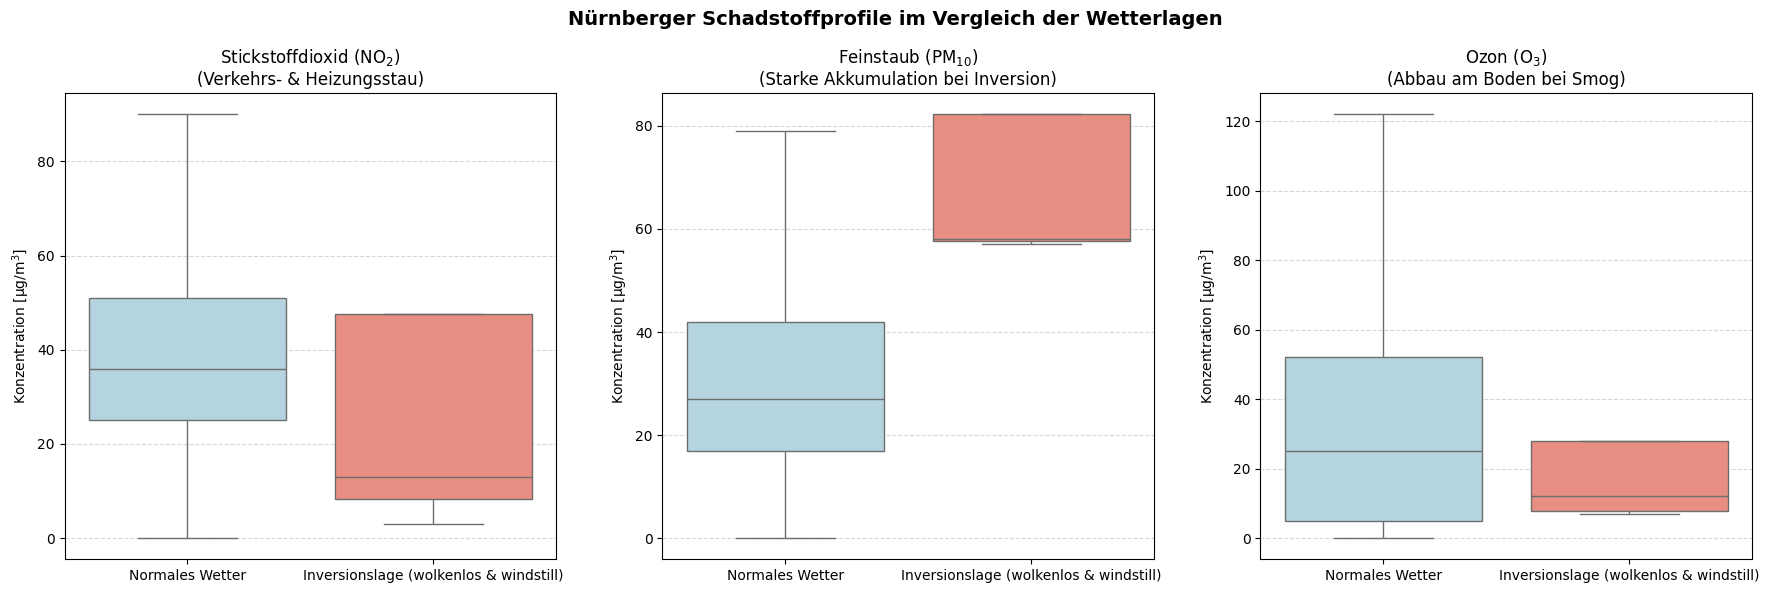

In [18]:
import numpy as np
df = dfRead.copy ()
# 1. Inversions-Maske über sekundäre Wetterdaten definieren
# (Sehr wenig Wind, kaum/keine Wolken, hoher Luftdruck)
inversions_wetter = (df['windgeschwindigkeit'] < 1.5) & \
                    (df['gesamtbewoelkung'] <= 2) & \
                    (df['luftdruck'] > 1020)

# Spalte für die Zuweisung erstellen (Zukunftssichere Seaborn-Syntax)
df['Wettertyp'] = np.where(inversions_wetter, 'Inversionslage (wolkenlos & windstill)', 'Normales Wetter')

# 2. Grafik erstellen: Vergleich aller drei Hauptschadstoffe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
schadstoffe = ['no2', 'pm10', 'o3']
farben = {'Normales Wetter': 'lightblue', 'Inversionslage (wolkenlos & windstill)': 'salmon'}

for i, schadstoff in enumerate(schadstoffe):
    sns.boxplot(
        ax=axes[i], 
        data=df, 
        x='Wettertyp', 
        y=schadstoff, 
        hue='Wettertyp', 
        palette=farben, 
        showfliers=False, 
        legend=False
    )
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Titel und Achsenbeschriftungen anpassen (mit r'' für LaTeX-Konformität)
axes[0].set_title(r'Stickstoffdioxid ($\mathrm{NO_2}$)' + '\n' + r'(Verkehrs- & Heizungsstau)')
axes[0].set_ylabel(r'Konzentration [$\mathrm{\mu g/m^3}$]')

axes[1].set_title(r'Feinstaub ($\mathrm{PM_{10}}$)' + '\n' + r'(Starke Akkumulation bei Inversion)')
axes[1].set_ylabel(r'Konzentration [$\mathrm{\mu g/m^3}$]')

axes[2].set_title(r'Ozon ($\mathrm{O_3}$)' + '\n' + r'(Abbau am Boden bei Smog)')
axes[2].set_ylabel(r'Konzentration [$\mathrm{\mu g/m^3}$]')

plt.suptitle('Nürnberger Schadstoffprofile im Vergleich der Wetterlagen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [42]:

df = pd.read_csv(r"Analyse/data.csv")


# ========================================================
# 1. DIRECT FIX: DATUM LIEGT BEREITS ALS 'YYYY-MM-DD' VOR
# ========================================================
# Wir wandeln die Spalte 'datum' direkt um und addieren die Stunden
df.index = pd.to_datetime(df['datum'], errors='coerce') + pd.to_timedelta(df['stunde'], unit='h')

# ========================================================
# 2. DATENBEREINIGUNG & NEUE DIAGNOSE
# ========================================================
df_clean = df.dropna(subset=['windgeschwindigkeit', 'luftdruck', 'no2']).copy()

df_clean['Jahr'] = df_clean.index.year
df_clean['Stunde'] = df_clean.index.hour
df_clean['Dekade'] = (df_clean['Jahr'] // 10) * 10

print("--- NEUE SICHERHEITS-DIAGNOSE ---")
print(f"Erster echter Zeitstempel: {df_clean.index.min()}")
print(f"Letzter echter Zeitstempel: {df_clean.index.max()}")
print(f"Anzahl unterschiedliche Jahre: {df_clean['Jahr'].nunique()}")
print(f"Erfasste Jahrzehnte: {sorted(df_clean['Dekade'].unique())}\n")

# ========================================================
# 3. SMOG-ANALYSE MIT REALEN GRENZWERTEN
# ========================================================
# Windstille in Nürnberg (<= 1.5 m/s) und starker Stations-Hochdruck (>= 992 hPa)
stunden_mit_smog = (df_clean['windgeschwindigkeit'] <= 1.5) & (df_clean['luftdruck'] >= 992)

# Auf Tage bündeln: Ein Tag zählt bei mindestens 4 Smog-Stunden
smog_stunden_pro_tag = stunden_mit_smog.resample('D').sum()
smog_tage = smog_stunden_pro_tag[smog_stunden_pro_tag >= 4]

# Auszählung nach Jahrzehnten
df_tage = pd.DataFrame(index=smog_tage.index)
df_tage['Dekade'] = (df_tage.index.year // 10) * 10
smog_pro_dekade = df_tage.groupby('Dekade').size()

print("--- FINALE BEREINIGTE SMOG-AUSWERTUNG ---")
print(f"Gesamtzahl aller echten Smog-Tage (1980-2024): {len(smog_tage)}")
if not smog_pro_dekade.empty:
    print("\nVerteilung nach Jahrzehnten:")
    print(smog_pro_dekade.to_string())


--- NEUE SICHERHEITS-DIAGNOSE ---
Erster echter Zeitstempel: 1980-04-03 00:00:00
Letzter echter Zeitstempel: 2024-12-31 23:00:00
Anzahl unterschiedliche Jahre: 45
Erfasste Jahrzehnte: [np.int32(1980), np.int32(1990), np.int32(2000), np.int32(2010), np.int32(2020)]

--- FINALE BEREINIGTE SMOG-AUSWERTUNG ---
Gesamtzahl aller echten Smog-Tage (1980-2024): 641

Verteilung nach Jahrzehnten:
Dekade
1980     38
1990    226
2000    144
2010    138
2020     95


--- SICHERHEITS-DIAGNOSE (AB 1990) ---
Erster Zeitstempel: 1990-01-01 00:00:00
Letzter Zeitstempel: 2024-12-31 23:00:00
Anzahl Jahre:       35
Jahrzehnte:          [np.int32(1990), np.int32(2000), np.int32(2010), np.int32(2020)]

--- FINALE BEREINIGTE SMOG-AUSWERTUNG (AB 1990) ---
Gesamtzahl echter Smog-Tage (1990-2024): 603

Verteilung nach Jahrzehnten:
Dekade
1990    226
2000    144
2010    138
2020     95


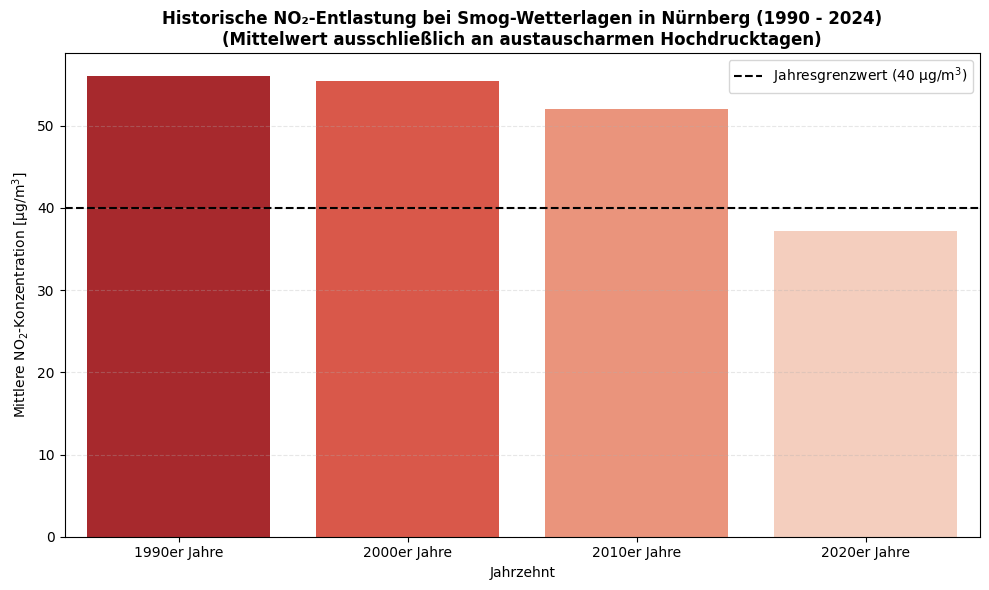

In [44]:
# ========================================================
# 1. TIME-INDEX BAUEN
# ========================================================
df.index = pd.to_datetime(df['datum'], errors='coerce') + pd.to_timedelta(df['stunde'], unit='h')

# ========================================================
# FIX: DATEN ERST AB 1990 FILTERN
# ========================================================
df = df[df.index >= '1990-01-01 00:00:00']

# ========================================================
# 2. DATENBEREINIGUNG & DIAGNOSE
# ========================================================
df_clean = df.dropna(subset=['windgeschwindigkeit', 'luftdruck', 'no2']).copy()

df_clean['Jahr'] = df_clean.index.year
df_clean['Stunde'] = df_clean.index.hour
df_clean['Dekade'] = (df_clean['Jahr'] // 10) * 10

print("--- SICHERHEITS-DIAGNOSE (AB 1990) ---")
print(f"Erster Zeitstempel: {df_clean.index.min()}")
print(f"Letzter Zeitstempel: {df_clean.index.max()}")
print(f"Anzahl Jahre:       {df_clean['Jahr'].nunique()}")
print(f"Jahrzehnte:          {sorted(df_clean['Dekade'].unique())}\n")

# ========================================================
# 3. SMOG-ANALYSE MIT REALEN GRENZWERTEN
# ========================================================
stunden_mit_smog = (df_clean['windgeschwindigkeit'] <= 1.5) & (df_clean['luftdruck'] >= 992)

# Auf Tage bündeln: Ein Tag zählt bei mindestens 4 Smog-Stunden
smog_stunden_pro_tag = stunden_mit_smog.resample('D').sum()
smog_tage = smog_stunden_pro_tag[smog_stunden_pro_tag >= 4]

# Auszählung nach Jahrzehnten
df_tage = pd.DataFrame(index=smog_tage.index)
df_tage['Dekade'] = (df_tage.index.year // 10) * 10
smog_pro_dekade = df_tage.groupby('Dekade').size()

print("--- FINALE BEREINIGTE SMOG-AUSWERTUNG (AB 1990) ---")
print(f"Gesamtzahl echter Smog-Tage (1990-2024): {len(smog_tage)}")
print("\nVerteilung nach Jahrzehnten:")
print(smog_pro_dekade.to_string())

# ========================================================
# 4. GRAFISCHER TREND DER SCHADSTOFFE AN SMOGTAGEN
# ========================================================
df_clean['Ist_Smogtag'] = stunden_mit_smog
df_nur_smog = df_clean[df_clean['Ist_Smogtag'] == True].copy()
df_nur_smog['Dekade_Str'] = df_nur_smog['Dekade'].astype(str) + 'er Jahre'

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_nur_smog, 
    x='Dekade_Str', 
    y='no2', 
    hue='Dekade_Str',
    palette='Reds_r', 
    errorbar=None,
    legend=False
)

plt.axhline(y=40, color='black', linestyle='--', label=r'Jahresgrenzwert ($40\ \mathrm{\mu g/m^3}$)')
plt.title('Historische NO₂-Entlastung bei Smog-Wetterlagen in Nürnberg (1990 - 2024)\n(Mittelwert ausschließlich an austauscharmen Hochdrucktagen)', fontsize=12, fontweight='bold')
plt.xlabel('Jahrzehnt')
plt.ylabel(r'Mittlere $\mathrm{NO_2}$-Konzentration [$\mathrm{\mu g/m^3}$]')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

--- SICHERHEITS-DIAGNOSE (AB 1990) ---
Erster Zeitstempel im Datensatz: 1990-01-01 00:00:00
Letzter Zeitstempel im Datensatz: 2024-12-31 23:00:00
Anzahl auswertbarer Jahre:       35
Gefundene Jahrzehnte:            [np.int32(1990), np.int32(2000), np.int32(2010), np.int32(2020)]

--- MITTLERE NO2-KONZENTRATION IM VERGLEICH [µg/m³] ---
Tagestyp    Normaltag  Smogtag
Dekade_Str                    
1990er          44.59    53.33
2000er          42.13    51.13
2010er          34.88    47.25
2020er          24.38    33.58

--- PROZENTUALER SCHADSTOFF-AUFSCHLAG AN SMOGTAGEN ---
Tagestyp    Smog-Aufschlag (%)
Dekade_Str                    
1990er                    19.6
2000er                    21.4
2010er                    35.5
2020er                    37.7

Gesamtzahl gefundener Smog-Tage (1990-2024): 603


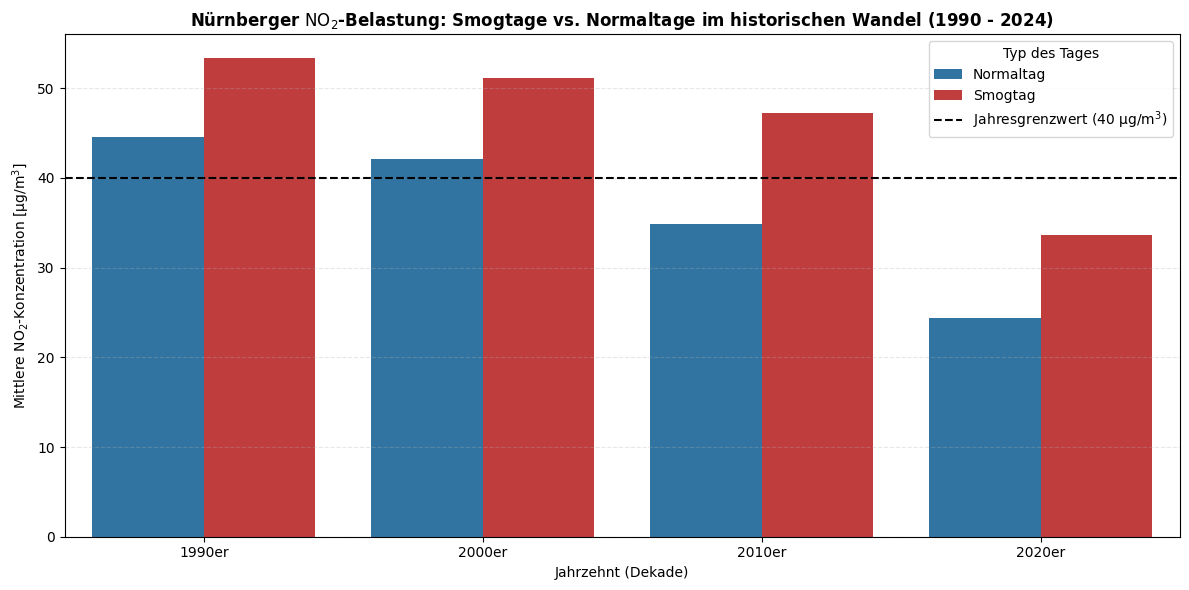

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========================================================
# 1. ZEIT-INDEX BAUEN & DATEN FILTERN (AB 1990)
# ========================================================
# Datum und Stunde verschmelzen und als DatetimeIndex setzen
df.index = pd.to_datetime(df['datum'], errors='coerce') + pd.to_timedelta(
    df['stunde'], unit='h'
)

# Harter Schnitt ab 1. Januar 1990 für verlässliche statistische Daten
df = df[df.index >= '1990-01-01 00:00:00']

# ========================================================
# 2. DATENBEREINIGUNG & ZEITKOMPONENTEN
# ========================================================
# Nur Zeilen behalten, in denen die Kernwerte vorhanden sind
df_clean = df.dropna(subset=['windgeschwindigkeit', 'luftdruck', 'no2']).copy()

# Zeitliche Unterteilungen für die Analyse berechnen
df_clean['Jahr'] = df_clean.index.year
df_clean['Dekade'] = (df_clean['Jahr'] // 10) * 10
df_clean['Dekade_Str'] = df_clean['Dekade'].astype(str) + 'er'

print('--- SICHERHEITS-DIAGNOSE (AB 1990) ---')
print(f'Erster Zeitstempel im Datensatz: {df_clean.index.min()}')
print(f'Letzter Zeitstempel im Datensatz: {df_clean.index.max()}')
print(f'Anzahl auswertbarer Jahre:       {df_clean["Jahr"].nunique()}')
print(f'Gefundene Jahrzehnte:            {sorted(df_clean["Dekade"].unique())}\n')

# ========================================================
# 3. SMOG-TAGE IDENTIFIZIEREN & ZUORDNEN
# ========================================================
# Definition für austauscharme Lagen (Windstille <= 1.5 m/s & Stations-Hochdruck >= 992 hPa)
stunden_mit_smog = (df_clean['windgeschwindigkeit'] <= 1.5) & (
    df_clean['luftdruck'] >= 992
)

# Auf Tage bündeln: Ein Tag zählt, wenn min. 4 Stunden Smog-Wetter herrschte
smog_stunden_pro_tag = stunden_mit_smog.resample('D').sum()
smog_tage_datumsliste = smog_stunden_pro_tag[smog_stunden_pro_tag >= 4].index.date

# Jede Stunde im Datensatz abgleichen: Gehört sie zu einem Smogtag oder Normaltag?
ist_smog_tag = (
    pd.Series(df_clean.index.date).isin(smog_tage_datumsliste).values
)
df_clean['Tagestyp'] = np.where(ist_smog_tag, 'Smogtag', 'Normaltag')

# ========================================================
# 4. NUMERISCHE STATISTIK-AUSGABE
# ========================================================
vergleich_tabelle = df_clean.groupby(
    ['Dekade_Str', 'Tagestyp'], observed=False
)['no2'].mean().unstack()

# Prozentualen Schadstoff-Aufschlag berechnen
vergleich_tabelle['Smog-Aufschlag (%)'] = (
    (vergleich_tabelle['Smogtag'] - vergleich_tabelle['Normaltag'])
    / vergleich_tabelle['Normaltag']
) * 100

print('--- MITTLERE NO2-KONZENTRATION IM VERGLEICH [µg/m³] ---')
print(vergleich_tabelle[['Normaltag', 'Smogtag']].round(2))
print('\n--- PROZENTUALER SCHADSTOFF-AUFSCHLAG AN SMOGTAGEN ---')
print(vergleich_tabelle[['Smog-Aufschlag (%)']].round(1))
print(f'\nGesamtzahl gefundener Smog-Tage (1990-2024): {len(smog_tage_datumsliste)}')

# ========================================================
# 5. GRAFISCHE DARSTELLUNG (Gruppiertes Balkendiagramm)
# ========================================================
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_clean,
    x='Dekade_Str',
    y='no2',
    hue='Tagestyp',
    palette={'Normaltag': 'tab:blue', 'Smogtag': 'tab:red'},
    errorbar=None,
)

# Offizielle Grenzwerte zur Orientierung einzeichnen (r'' verhindert SyntaxWarnings)
plt.axhline(
    y=40,
    color='black',
    linestyle='--',
    label=r'Jahresgrenzwert ($40\ \mathrm{\mu g/m^3}$)',
)

plt.title(
    r'Nürnberger $\mathrm{NO_2}$-Belastung: Smogtage vs. Normaltage im historischen Wandel (1990 - 2024)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Jahrzehnt (Dekade)')
plt.ylabel(r'Mittlere $\mathrm{NO_2}$-Konzentration [$\mathrm{\mu g/m^3}$]')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Typ des Tages', loc='upper right')

plt.tight_layout()
plt.show()


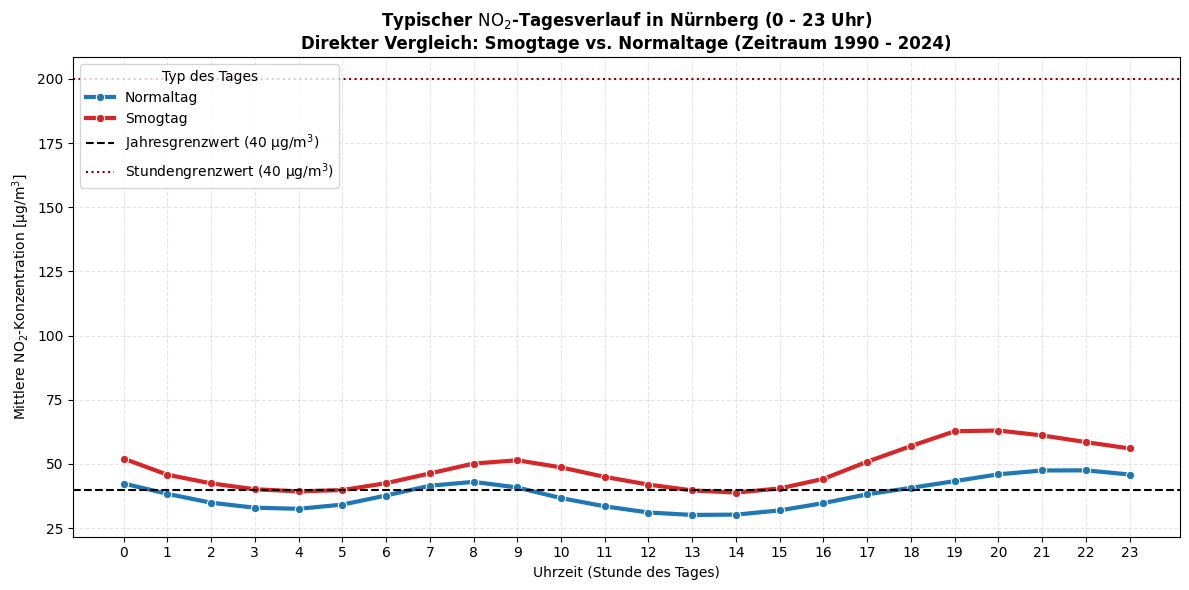

In [49]:
# ========================================================
# 1. TIME-INDEX & 1990-FILTER (Sicherheitsbasis)
# ========================================================
df.index = pd.to_datetime(df['datum'], errors='coerce') + pd.to_timedelta(
    df['stunde'], unit='h'
)
df = df[df.index >= '1990-01-01 00:00:00']

# ========================================================
# 2. DATENBEREINIGUNG & ZEITKOMPONENTEN
# ========================================================
df_clean = df.dropna(subset=['windgeschwindigkeit', 'luftdruck', 'no2']).copy()
df_clean['Stunde_Achse'] = df_clean.index.hour

# ========================================================
# 3. SMOG-TAGE IDENTIFIZIEREN
# ========================================================
stunden_mit_smog = (df_clean['windgeschwindigkeit'] <= 1.5) & (
    df_clean['luftdruck'] >= 992
)
smog_stunden_pro_tag = stunden_mit_smog.resample('D').sum()
smog_tage_datumsliste = smog_stunden_pro_tag[smog_stunden_pro_tag >= 4].index.date

# Tagestyp zuweisen
ist_smog_tag = (
    pd.Series(df_clean.index.date).isin(smog_tage_datumsliste).values
)
df_clean['Tagestyp'] = np.where(ist_smog_tag, 'Smogtag', 'Normaltag')

# ========================================================
# 4. GRAFISCHE DARSTELLUNG (Stündlicher Tagesverlauf)
# ========================================================
plt.figure(figsize=(12, 6))

# Linienplot für den mittleren Tagesverlauf
sns.lineplot(
    data=df_clean,
    x='Stunde_Achse',
    y='no2',
    hue='Tagestyp',
    palette={'Normaltag': 'tab:blue', 'Smogtag': 'tab:red'},
    linewidth=3,
    marker='o',
    errorbar=None,  # Zeigt den reinen Mittelwert ohne schattiertes Konfidenzintervall
)

# Gesetzliche Grenzwerte zur Orientierung
plt.axhline(
    y=40,
    color='black',
    linestyle='--',
    label=r'Jahresgrenzwert ($40\ \mathrm{\mu g/m^3}$)',
)
plt.axhline(
    y=200,
    color='darkred',
    linestyle=':',
    label=r'Stundengrenzwert ($40\ \mathrm{\mu g/m^3}$)',
)

# Achsen- und Titelbeschriftung (r'' schützt vor SyntaxWarnings)
plt.title(
    r'Typischer $\mathrm{NO_2}$-Tagesverlauf in Nürnberg (0 - 23 Uhr)'
    + '\n'
    + 'Direkter Vergleich: Smogtage vs. Normaltage (Zeitraum 1990 - 2024)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Uhrzeit (Stunde des Tages)', fontsize=10)
plt.ylabel(r'Mittlere $\mathrm{NO_2}$-Konzentration [$\mathrm{\mu g/m^3}$]', fontsize=10)

# X-Achse stündlich von 0 bis 23 beschriften
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Typ des Tages', loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
tem = 
luftdruck = 1025
bew = 